# Chapter 5, Example 1b
## Random subsampling to determine the number of hidden neurons

In [1]:
import torch
from torch import nn

from sklearn import datasets

import numpy as np
import matplotlib.pyplot as plt

### Read iris data and preprocess

In [2]:
# read data
iris = datasets.load_iris()

no_data = len(iris.data)
no_features = np.shape(iris.data)[1]
no_labels = len(np.unique(iris.target))

# center the data
X = iris.data - np.mean(iris.data, axis=0)
Y = iris.target

### Build the network

In [ ]:
class FFN(nn.Module):
    def __init__(self, no_features, no_hidden, no_labels):
        super().__init__()
        self.relu_stack = nn.Sequential(
            nn.Linear(no_features, no_hidden),
            nn.ReLU(),
            nn.Linear(no_hidden, no_labels)
        )

    def forward(self, x):
        logits = self.relu_stack(torch.tensor(x, dtype=torch.float32))
        return logits

### Define the training experiment

In [7]:
def train_exp(X, Y, no_features, no_labels, hidden_units, no_epochs=1000, lr=0.01):

    x_train, y_train, x_test, y_test = X[:100], Y[:100], X[100:], Y[100:]
    
    loss_fn = torch.nn.CrossEntropyLoss()
    
    acc = []
    for no_hidden in hidden_units:
        
        model = FFN(no_features, no_hidden, no_labels)
    
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)

        for epoch in range(no_epochs):
            pred = model(x_train)
            loss = loss_fn(pred, torch.tensor(y_train, dtype=torch.long))
            
    
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        pred = model(x_test)
        acc_ = (pred.argmax(1) == torch.tensor(y_test, dtype=torch.long)).type(torch.float).mean()
        
        acc.append(acc_.item())
        
    return acc

### Perform experiments

In [8]:
no_epochs = 1000
lr = 0.1
no_exps = 10
hidden_units = [2, 4, 6, 8, 10, 12]

seed = 10
torch.manual_seed(seed)
np.random.seed(seed)

acc = []
idx = np.arange(no_data)
for exp in range(no_exps):
        
    np.random.shuffle(idx)

    acc.append(train_exp(X[idx], Y[idx], no_features, no_labels, hidden_units, no_epochs, lr))
    print('exp %d, acc %s'%(exp, np.round(acc[exp], 3)))

mean_acc = np.mean(np.array(acc), axis = 0)
print("mean accuracy %s"%np.round(mean_acc,3))
print('* optimum hidden units %d *'%hidden_units[np.argmax(mean_acc)])

exp 0, acc [1. 1. 1. 1. 1. 1.]
exp 1, acc [0.98 0.96 0.98 0.98 0.98 0.98]
exp 2, acc [0.92 0.92 0.92 0.92 0.92 0.92]
exp 3, acc [0.98 0.98 0.98 0.98 0.98 0.98]
exp 4, acc [0.96 0.96 0.96 0.96 0.96 0.96]
exp 5, acc [0.98 1.   1.   1.   1.   0.98]
exp 6, acc [0.32 0.98 0.98 0.98 0.98 0.98]
exp 7, acc [0.98 0.98 0.98 0.96 0.98 0.98]
exp 8, acc [0.9  0.92 0.88 0.9  0.9  0.88]
exp 9, acc [0.96 0.96 0.96 0.96 0.96 0.96]
mean accuracy [0.898 0.966 0.964 0.964 0.966 0.962]
* optimum hidden units 4 *


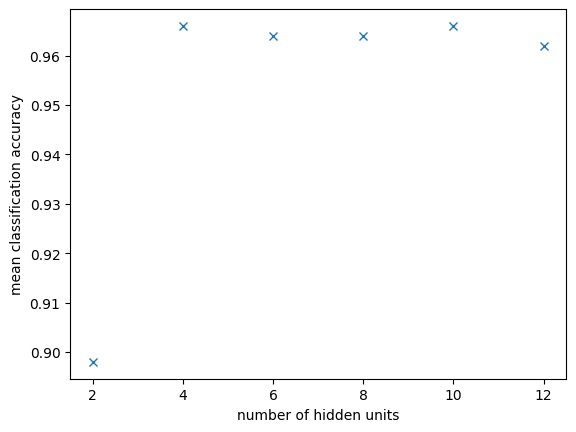

In [9]:
plt.figure(1)
plt.plot(hidden_units, mean_acc, marker = 'x', linestyle = 'None')
plt.xlabel('number of hidden units')
plt.ylabel('mean classification accuracy')
plt.show()